In [ ]:
import torch
from torch.utils.data.dataset import Dataset
import os
import pandas as pd
import cv2
import kagglehub  # Ensure you have run: pip install kagglehub

class CUB200(Dataset):
    def __init__(self, data_set_root, image_size, transform, test_train=1, return_masks=False, class_limit=50):
        # 1. Download/Path via kagglehub
        # This returns the local path to the dataset
        # Adjust paths based on the Kaggle directory structure
        self.data_set_root = data_set_root

        base_path = os.path.join(self.data_set_root, "CUB_200_2011")

        class_list_path = os.path.join(base_path, "image_class_labels.txt")
        self.data_df = pd.read_csv(class_list_path, sep=" ", names=["index", "class"])

        data_list_path = os.path.join(base_path, "images.txt")
        cub200_df = pd.read_csv(data_list_path, sep=" ", names=["index", "file_path"])

        bbox_list_path = os.path.join(base_path, "bounding_boxes.txt")
        bbox_df = pd.read_csv(bbox_list_path, sep=" ", names=["index", "x", "y", "width", "height"])

        # Note: test_train_split.txt is usually inside the base_path in the CUB dataset
        split_path = os.path.join(base_path, "train_test_split.txt")
        split_df = pd.read_csv(split_path, sep=" ", names=["index", "split"])

        # Merging logic
        self.data_df = self.data_df.merge(cub200_df, on='index')
        self.data_df = self.data_df.merge(bbox_df, on='index')
        self.data_df = self.data_df.merge(split_df, on='index')

        # --- NEW: Class Filtering Logic ---
        # We filter for the first 'class_limit' classes (CUB classes are 1-indexed)
        if class_limit is not None:
            self.data_df = self.data_df[self.data_df['class'] <= class_limit]
        # ----------------------------------

        # Filter by split (Train/Test)
        self.data_df = self.data_df[self.data_df.split != test_train]

        self.return_masks = return_masks
        self.image_size = image_size
        self.transform = transform

        self.image_root_dir = os.path.join(base_path, "images")
        # Segments are usually at the same level as the CUB_200_2011 folder
        self.mask_root_dir = os.path.join(self.data_set_root, "segmentations")

    def get_bbox_list(self, data, img_size):
        bbox_array = [data["x"], data["y"], data["width"], data["height"]]

        # Clipping logic
        if (bbox_array[0] + bbox_array[2]) > img_size[1]:
            bbox_array[2] = img_size[1] - bbox_array[0]
        if (bbox_array[1] + bbox_array[3]) > img_size[0]:
            bbox_array[3] = img_size[0] - bbox_array[1]

        return [bbox_array]

    def get_output_tensors(self, data_out):
        if len(data_out["bboxes"]) > 0:
            bbox = torch.FloatTensor(data_out["bboxes"][0]) / self.image_size
            label = data_out["class_labels"][0]
        else:
            bbox = torch.zeros(4)
            label = -1
        return bbox, [label]

    def __getitem__(self, index):
        # Use iloc correctly to get the row
        data_series = self.data_df.iloc[index]
        file_path = data_series["file_path"]
        label = data_series["class"]

        img_path = os.path.join(self.image_root_dir, file_path)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        bbox_array = self.get_bbox_list(data_series, image.shape)

        if self.return_masks:
            mask_path = os.path.join(self.mask_root_dir, file_path).replace(".jpg", ".png")
            mask = cv2.imread(mask_path)

            # Albumentations call
            data_out = self.transform(image=image, bboxes=bbox_array, mask=mask, class_labels=[label])
            bbox, label = self.get_output_tensors(data_out)
            mask = (data_out["mask"][:, :, 0] > 100).long()

            return data_out["image"], mask, bbox, label
        else:
            data_out = self.transform(image=image, bboxes=bbox_array, class_labels=[label])
            bbox, label = self.get_output_tensors(data_out)

            return data_out["image"], bbox, label

    def __len__(self):
        return len(self.data_df)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data.dataloader as dataloader

import os
from tqdm.notebook import trange, tqdm


class ModelTrainer(nn.Module):
    def __init__(self, model, output_size, device, loss_fun, batch_size, learning_rate, save_dir, model_name,
                 eval_metric, start_from_checkpoint=False, run_evaluate=True):

        # Call the __init__ function of the parent nn.module class
        super(ModelTrainer, self).__init__()
        self.optimizer = None

        self.device = device
        self.loss_fun = loss_fun
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.start_epoch = 0
        self.best_valid_acc = 0

        self.train_loss_logger = []
        self.train_acc_logger = []
        self.val_acc_logger = []

        self.train_loader = None
        self.test_loader = None
        self.valid_loader = None

        self.output_size = output_size

        self.model = self.change_output(model, output_size=output_size)
        self.set_optimizer()
        self.scaler = torch.cuda.amp.GradScaler()

        self.save_path = os.path.join(save_dir, model_name + ".pt")
        self.save_dir = save_dir

        self.lr_schedule = None
        self.run_evaluate = run_evaluate
        self.eval_metric = eval_metric

        # Create Save Path from save_dir and model_name, we will save and load our checkpoint here
        # Create the save directory if it does note exist
        if not os.path.isdir(self.save_dir):
            os.makedirs(self.save_dir)

        if start_from_checkpoint:
            self.load_checkpoint()
        else:
            # If checkpoint does exist and start_from_checkpoint = False
            # Raise an error to prevent accidental overwriting
            if os.path.isfile(self.save_path):
                raise ValueError("Warning Checkpoint exists")
            else:
                print("Starting from scratch")

    def __get_layer__(self, num_ftrs, output_size):

        layer = nn.Linear(num_ftrs, output_size).to(self.device)

        return layer

    def change_output(self, model, output_size):

        if output_size > 0:
            if hasattr(model, "fc"):
                num_ftrs = model.fc.in_features
                model.fc = self.__get_layer__(num_ftrs, output_size)
            elif hasattr(model, "classifier"):
                if isinstance(model.classifier, nn.Linear):
                    num_ftrs = model.classifier.in_features
                    model.classifier = self.__get_layer__(num_ftrs, output_size)
                if isinstance(model.classifier, nn.Sequential):
                    num_ftrs = model.classifier[-1].in_features
                    model.classifier[-1] = self.__get_layer__(num_ftrs, output_size)
            elif hasattr(model, "heads"):
                if isinstance(model.heads, nn.Linear):
                    num_ftrs = model.heads.in_features
                    model.heads = self.__get_layer__(num_ftrs, output_size)
                if isinstance(model.heads, nn.Sequential):
                    num_ftrs = model.heads[-1].in_features
                    model.heads[-1] = self.__get_layer__(num_ftrs, output_size)

        return model

    def set_optimizer(self):
        self.optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)

    def set_lr_schedule(self, lr_schedule):
        self.lr_schedule = lr_schedule

    def load_checkpoint(self):
        # Check if checkpoint exists
        if os.path.isfile(self.save_path):
            # Load Checkpoint
            check_point = torch.load(self.save_path)

            # Checkpoint is saved as a python dictionary
            # Here we unpack the dictionary to get our previous training states
            self.model.load_state_dict(check_point['model_state_dict'])
            self.optimizer.load_state_dict(check_point['optimizer_state_dict'])

            self.start_epoch = check_point['epoch']
            self.best_valid_acc = check_point['best_valid_acc']

            self.train_loss_logger = check_point['train_loss_logger']
            self.train_acc_logger = check_point['train_acc_logger']
            self.val_acc_logger = check_point['val_acc_logger']

            print("Checkpoint loaded, starting from epoch:", self.start_epoch)
        else:
            # Raise Error if it does not exist
            raise ValueError("Checkpoint Does not exist")

    def save_checkpoint(self, epoch, valid_acc):
        self.best_valid_acc = valid_acc

        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_valid_acc': valid_acc,
            'train_loss_logger': self.train_loss_logger,
            'train_acc_logger': self.train_acc_logger,
            'val_acc_logger': self.val_acc_logger,
        }, self.save_path)

    def set_data(self, train_set, test_set, val_set):

        print(f'Number of training examples: {len(train_set)}')
        print(f'Number of validation examples: {len(val_set)}')
        print(f'Number of testing examples: {len(test_set)}')

        self.train_loader = dataloader.DataLoader(train_set, shuffle=True, batch_size=self.batch_size, num_workers=8)
        self.valid_loader = dataloader.DataLoader(val_set, shuffle=True, batch_size=self.batch_size, num_workers=8)
        self.test_loader = dataloader.DataLoader(test_set, shuffle=True, batch_size=self.batch_size, num_workers=8)

    def run_training(self, num_epochs):
        valid_acc = 0
        train_acc = 0

        pbar = trange(self.start_epoch, num_epochs, leave=False, desc="Epoch")
        for epoch in pbar:
            pbar.set_postfix_str('IoU: Train %.2f, Val %.2f' % (train_acc, valid_acc))

            # Call the training function and pass training dataloader etc
            self.train_model()

            if self.run_evaluate:
                # Call the modules evaluate function for train and validation set
                train_acc = self.evaluate_model(train_test_val="train")
                valid_acc = self.evaluate_model(train_test_val="val")

                # Check if the current validation accuracy is greater than the previous best
                # If so, then save the model
                if valid_acc > self.best_valid_acc:
                    self.save_checkpoint(epoch, valid_acc)
            else:
                self.save_checkpoint(epoch, 0)

            if self.lr_schedule is not None:
                self.lr_schedule.step()

    # This function should perform a single training epoch using our training data
    def train_model(self):

        if self.train_loader is None:
            ValueError("Dataset not defined!")

        # Set Network in train mode
        self.train()
        for i, data in enumerate(tqdm(self.train_loader, leave=False, desc="Training")):
            with torch.cuda.amp.autocast():
                # Forward pass of image through network and get output
                fx = self.forward(data[0].to(self.device))

                # Calculate loss using loss function
                loss = self.loss_fun(fx, data[1].to(self.device))

            # Zero gradients
            self.optimizer.zero_grad()
            # Backpropagate gradients
            self.scaler.scale(loss).backward()
            # Clip grads
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.parameters(), 5)
            # Do a single optimization step
            self.scaler.step(self.optimizer)
            self.scaler.update()

            # Log the loss for plotting
            self.train_loss_logger.append(loss.item())

    # This function should perform a single evaluation epoch, it WILL NOT be used to train our model
    def evaluate_model(self, train_test_val="test"):
        if self.test_loader is None:
            ValueError("Dataset not defined!")

        state = "Evaluating "
        if train_test_val == "test":
            loader = self.test_loader
            state += "Test Set"
        elif train_test_val == "train":
            loader = self.train_loader
            state += "Train Set"
        elif train_test_val == "val":
            loader = self.valid_loader
            state += "Validation Set"
        else:
            ValueError("Invalid dataset, train_test_val should be train/test/val")

        # Initialise counter
        epoch_acc = 0
        self.eval()
        with torch.no_grad():
            for i, data in enumerate(tqdm(loader, leave=False, desc=state)):
                with torch.cuda.amp.autocast():
                    # Forward pass of image through network
                    fx = self.forward(data[0].to(self.device))

                    # Log the cumulative sum of the acc
                    epoch_acc += self.eval_metric(fx, data).sum().cpu().item()

        # Log the accuracy from the epoch
        if train_test_val == "train":
            self.train_acc_logger.append(epoch_acc / len(loader.dataset))
        elif train_test_val == "val":
            self.val_acc_logger.append(epoch_acc / len(loader.dataset))

        return epoch_acc / len(loader.dataset)

    def forward(self, x):
        return self.model(x)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader as dataloader
import torchvision.models as models

# You'll need to install albumentations!
import albumentations as A
from albumentations.pytorch import ToTensorV2

import time
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange, tqdm
from PIL import Image, ImageOps
import copy
import pandas as pd


In [ ]:
# # The size of our mini batches
# batch_size = 64

# # How many itterations of our dataset
# num_epochs = 50

# # Optimizer learning rate
# learning_rate = 1e-4

# # You'll need to Download Dataset found here
# # https://www.kaggle.com/datasets/wenewone/cub2002011
# # Unzip and rename to cub_200
# # Where to load/save the dataset from
# data_set_root = "../../datasets/cub_200"

# # What to resize our images to
# image_size = 128

In [ ]:
import kagglehub

# --- Training Hyperparameters ---
batch_size = 64
num_epochs = 50
learning_rate = 1e-4

# --- Dataset Configuration ---
# What to resize our images to
image_size = 128

# NEW: Limit to the first 50 classes for faster training
class_limit = 50

# Automated download via kagglehub (replaces manual pathing)
# This will return the path where the dataset is stored/cached
data_set_root = kagglehub.dataset_download("wenewone/cub2002011")

print(f"Dataset location: {data_set_root}")

Using Colab cache for faster access to the 'cub2002011' dataset.
Dataset location: /kaggle/input/cub2002011


In [ ]:
start_from_checkpoint = False

save_dir = '../data/Models'
model_name = 'ResNet34_CUB'

In [ ]:
# Set device to GPU_indx if GPU is avaliable
gpu_indx = 0
device = torch.device(gpu_indx if torch.cuda.is_available() else 'cpu')

In [ ]:
train_transform = A.Compose([A.SmallestMaxSize(max_size=image_size),
                             A.RandomCrop(height=image_size, width=image_size),
                             A.HorizontalFlip(p=0.5),
                             A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
                             A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.5),
                             A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
                             A.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225]),
                            ToTensorV2()],
                            bbox_params=A.BboxParams(format='coco',
                                                     min_area=0, min_visibility=0.0,
                                                     label_fields=['class_labels']))

transform = A.Compose([A.SmallestMaxSize(max_size=image_size),
                       A.RandomCrop(height=image_size, width=image_size),
                       A.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225]),
                       ToTensorV2()],
                      bbox_params=A.BboxParams(format='coco',
                                               min_area=0, min_visibility=0.0,
                                               label_fields=['class_labels']))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Intersection over Union (IoU)
To train our model to correctly predict the bounding box we're going to use logistic regression. However to calulate the performance of our model (and the accuracy of the predicted bounding boxes) we're going to use the [Intersection over Union](https://medium.com/analytics-vidhya/iou-intersection-over-union-705a39e7acef) metric.

In [ ]:
# nn.Module class that will return the IoU for a batch of outputs
class BboxIOU(nn.Module):

    def xyhw_to_xyxy(self, bbox):
        """
        Converts from (x_min, y_min, width, height) to (x_min, y_min, x_max, y_max) format
        """
        new_bbox = torch.cat((bbox[:, 0:1],
                              bbox[:, 1:2],
                              bbox[:, 2:3] + bbox[:, 0:1],
                              bbox[:, 3:4] + bbox[:, 1:2]), 1)
        return new_bbox

    def bb_intersection_over_union(self, pred_xyhw, target_xyhw):
        pred_xyxy = self.xyhw_to_xyxy(pred_xyhw)
        target_xyxy = self.xyhw_to_xyxy(target_xyhw)

        # Determine the (x, y)-coordinates of the intersection rectangle
        xA = torch.cat((pred_xyxy[:, 0:1], target_xyxy[:, 0:1]), 1).max(dim=1)[0].unsqueeze(1)
        yA = torch.cat((pred_xyxy[:, 1:2], target_xyxy[:, 1:2]), 1).max(dim=1)[0].unsqueeze(1)
        xB = torch.cat((pred_xyxy[:, 2:3], target_xyxy[:, 2:3]), 1).min(dim=1)[0].unsqueeze(1)
        yB = torch.cat((pred_xyxy[:, 3:4], target_xyxy[:, 3:4]), 1).min(dim=1)[0].unsqueeze(1)

        # Compute the area of intersection rectangle
        x_len = F.relu(xB - xA)
        y_len = F.relu(yB - yA)
        # Negative area means no overlap
        interArea = x_len * y_len

        # If you don't have xyhw values, calculate areas like this
#         w1 = (pred_xyxy[:, 0:1] - pred_xyxy[:, 2:3]).abs()
#         h1 = (pred_xyxy[:, 1:2] - pred_xyxy[:, 3:4]).abs()

#         w2 = (target_xyxy[:, 0:1] - target_xyxy[:, 2:3]).abs()
#         h2 = (target_xyxy[:, 1:2] - target_xyxy[:, 3:4]).abs()

#         area1 = w1 * h1
#         area2 = w2 * h2

        area1 = pred_xyhw[:, 2:3] * pred_xyhw[:, 3:4]
        area2 = target_xyhw[:, 2:3] * target_xyhw[:, 3:4]

        # Compute the intersection over union by taking the intersection
        # area and dividing it by the sum of prediction + ground-truth
        # areas - the interesection area
        iou = interArea / (area1 + area2 - interArea + 1e-5)

        # Return the intersection over union value
        return iou

    def forward(self, predictions, data):
        """
        data: list of data, index 0 is the input image index [0] is the target
        predictions: raw output of the model, the first 4 outputs are assumed to be the bounding box values
        """

        pred_bbox = torch.sigmoid(predictions[:, :4])
        target_bbox = data[1].to(pred_bbox.device)

        return self.bb_intersection_over_union(pred_bbox, target_bbox)

# Create the training, testing and validation data

In [ ]:
# Define our Datasets
# You'll need to download the dataset from Kaggle
# https://www.kaggle.com/datasets/wenewone/cub2002011
# Unzip it (and the directories it contains) into the datasets directory
# and rename the top-level directory cub_200

train_data = CUB200(data_set_root, image_size=image_size,
                    transform=train_transform, test_train=0)

test_data = CUB200(data_set_root, image_size=image_size,
                   transform=transform, test_train=1)

# Split trainging data into train and validation set with 90/10% traning/validation split
validation_split = 0.9

n_train_examples = int(len(train_data)*validation_split)
n_valid_examples = len(train_data) - n_train_examples
train_data, valid_data = torch.utils.data.random_split(train_data, [n_train_examples, n_valid_examples],
                                                       generator=torch.Generator().manual_seed(42))

# Create the Pretrained Network

In [ ]:
# Create an instance of the ResNet34 Model
# res_net = models.resnet34(pretrained=True)
# or
res_net = models.resnet34(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 198MB/s]


In [ ]:
model_trainer = ModelTrainer(model=res_net.to(device), output_size=4, device=device,
                             loss_fun=nn.BCEWithLogitsLoss(), batch_size=batch_size,
                             learning_rate=learning_rate, save_dir=save_dir, model_name=model_name,
                             eval_metric=BboxIOU(), start_from_checkpoint=start_from_checkpoint)

Starting from scratch


/tmp/ipython-input-1952996247.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [ ]:
model_trainer.set_data(train_set=train_data, test_set=test_data, val_set=valid_data)

Number of training examples: 1350
Number of validation examples: 150
Number of testing examples: 1389


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Set a Learning Rate Scheduler
We can dynamically change the <a href="https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate">learning rate</a> during training to help our model converge to a better minimum!

In [ ]:
model_trainer.set_lr_schedule(optim.lr_scheduler.StepLR(model_trainer.optimizer,
                                                        step_size=1,
                                                        gamma=0.95))

# View Data

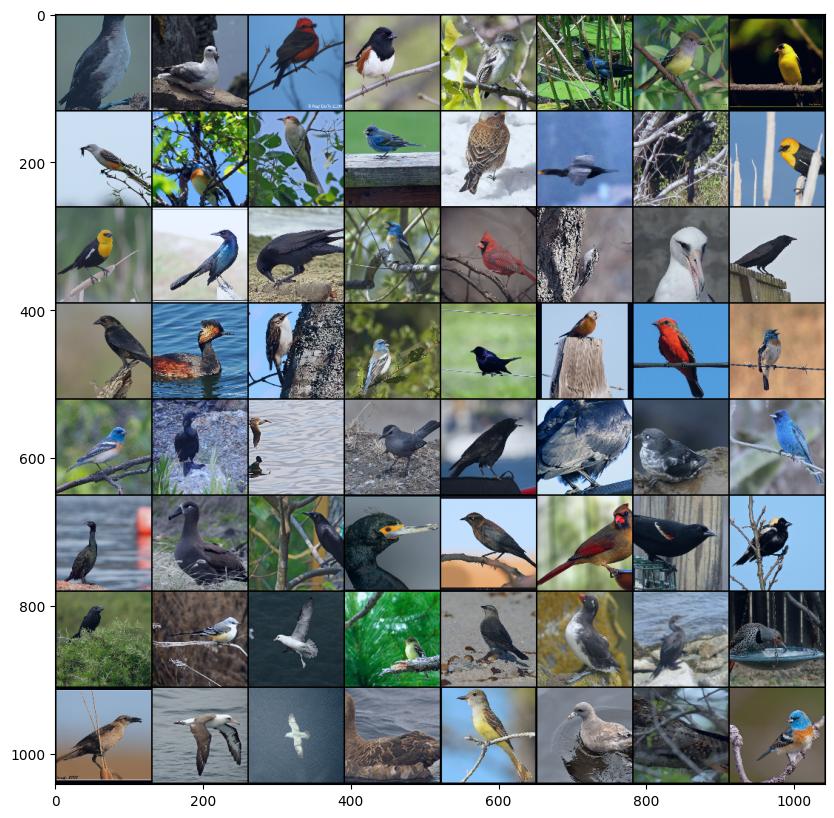

In [ ]:
plt.figure(figsize = (20,10))
images, bbox, labels = next(iter(model_trainer.test_loader))
out = torchvision.utils.make_grid(images, normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

In [ ]:
example_indx = 3
ex_img = images[example_indx]

# The bounding box is represented in the (x_min, y_min, width, height) format
# aka the coordinate of the top left corner of the box and the box height and width

# draw_bounding_boxes expects it in the (x_min, y_min, x_max, y_max) formatweights=ResNet18_Weights.IMAGENET1K_V1
# aka the coordinates of the top left and bottom right corners of the box
ex_label = bbox[example_indx].unsqueeze(0) * image_size
ex_label[:, 2] += ex_label[:, 0]
ex_label[:, 3] += ex_label[:, 1]

img_out = (((ex_img - ex_img.min())/(ex_img.max() - ex_img.min())) * 255).to(torch.uint8)
img_box = torchvision.utils.draw_bounding_boxes(img_out, ex_label, colors=(0, 255, 0))

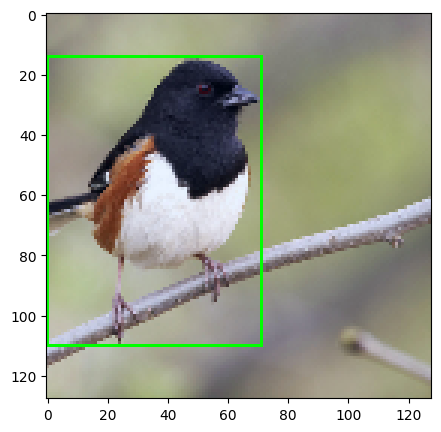

In [ ]:
plt.figure(figsize = (5,5))
out = torchvision.utils.make_grid(img_box.unsqueeze(0).float(), normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

In [ ]:
# Lets see how many Parameter's our Model has!
num_params = 0
for param in model_trainer.model.parameters():
    num_params += param.flatten().shape[0]
print("This model has %d (approximately %d Million) Parameters!" % (num_params, num_params//1e6))

This model has 21286724 (approximately 21 Million) Parameters!


# Train Model!
Our full training method is now fully contained within the trainner class! Simply run the run_training method and specify how many epochs it should train for!

In [ ]:
model_trainer.run_training(num_epochs=num_epochs)

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipython-input-1952996247.py:177: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Evaluating Train Set:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipython-input-1952996247.py:221: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Evaluating Train Set:   0%|          | 0/22 [00:00<?, ?it/s]

Evaluating Validation Set:   0%|          | 0/3 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Evaluating Train Set:   0%|          | 0/22 [00:00<?, ?it/s]

Evaluating Validation Set:   0%|          | 0/3 [00:00<?, ?it/s]

# View Results

In [ ]:
print("The highest validation IoU was %.2f" %(model_trainer.best_valid_acc))

The highest validation IoU was 0.79


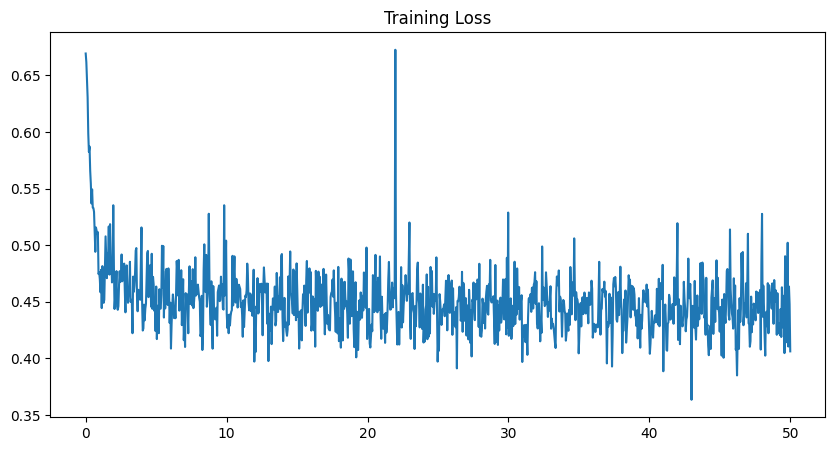

In [ ]:
_ = plt.figure(figsize = (10,5))
train_x = np.linspace(0, num_epochs, len(model_trainer.train_loss_logger))
_ = plt.plot(train_x, model_trainer.train_loss_logger)
_ = plt.title("Training Loss")

## Model Prediction!

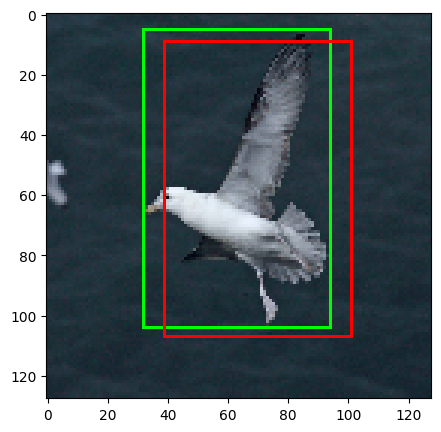

In [ ]:
# Select an image to test
example_indx = 50
ex_img = images[example_indx]
img_out = (((ex_img - ex_img.min())/(ex_img.max() - ex_img.min())) * 255).to(torch.uint8)

real_label = bbox[example_indx].unsqueeze(0) * image_size
real_label[:, 2] += real_label[:, 0]
real_label[:, 3] += real_label[:, 1]

# Get the model's prediction for the Bounding Box
model_trainer.eval()
with torch.no_grad():
    pred_out = torch.sigmoid(model_trainer(ex_img.unsqueeze(0).to(device)))
    pred_label = (pred_out * image_size).cpu()
    pred_label[:, 2] += pred_label[:, 0]
    pred_label[:, 3] += pred_label[:, 1]

# Draw the box on the image
img_box = torchvision.utils.draw_bounding_boxes(img_out, real_label, colors=(0, 255, 0))
img_box = torchvision.utils.draw_bounding_boxes(img_box, pred_label, colors=(255, 0, 0))

plt.figure(figsize = (5,5))
out = torchvision.utils.make_grid(img_box.unsqueeze(0).float(), normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

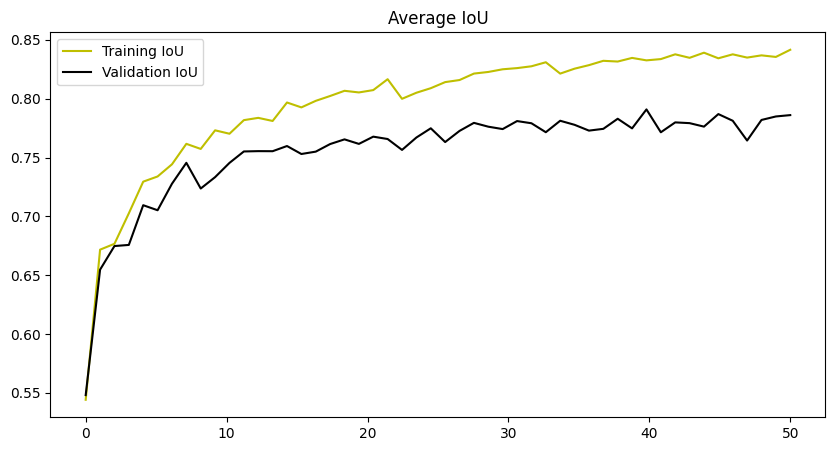

In [ ]:
_ = plt.figure(figsize = (10,5))
train_x = np.linspace(0, num_epochs, len(model_trainer.train_acc_logger))
_ = plt.plot(train_x, model_trainer.train_acc_logger, c = "y")
valid_x = np.linspace(0, num_epochs, len(model_trainer.val_acc_logger))
_ = plt.plot(valid_x, model_trainer.val_acc_logger, c = "k")

_ = plt.title("Average IoU")
_ = plt.legend(["Training IoU", "Validation IoU"])

# Evaluate

In [ ]:
# Call the evaluate function and pass the evaluation/test dataloader etc
test_acc = model_trainer.evaluate_model(train_test_val="test")
print("The Test Average IoU is: %.2f" %(test_acc))

Evaluating Test Set:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipython-input-1952996247.py:221: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


The Test Average IoU is: 0.77
